In [3]:
!pip install yfinance --upgrade --quiet

[*********************100%***********************]  1 of 1 completed


Descriptive Statistics:
Mean Daily Return: 0.3672%
Standard Deviation: 3.1297%
Minimum Daily Return: -16.97%
Maximum Daily Return: 24.37%

Value-at-Risk (95% confidence):
Historical VaR: -4.14%
Monte Carlo VaR: -4.75%
Historical Expected Shortfall (ES): -6.20%


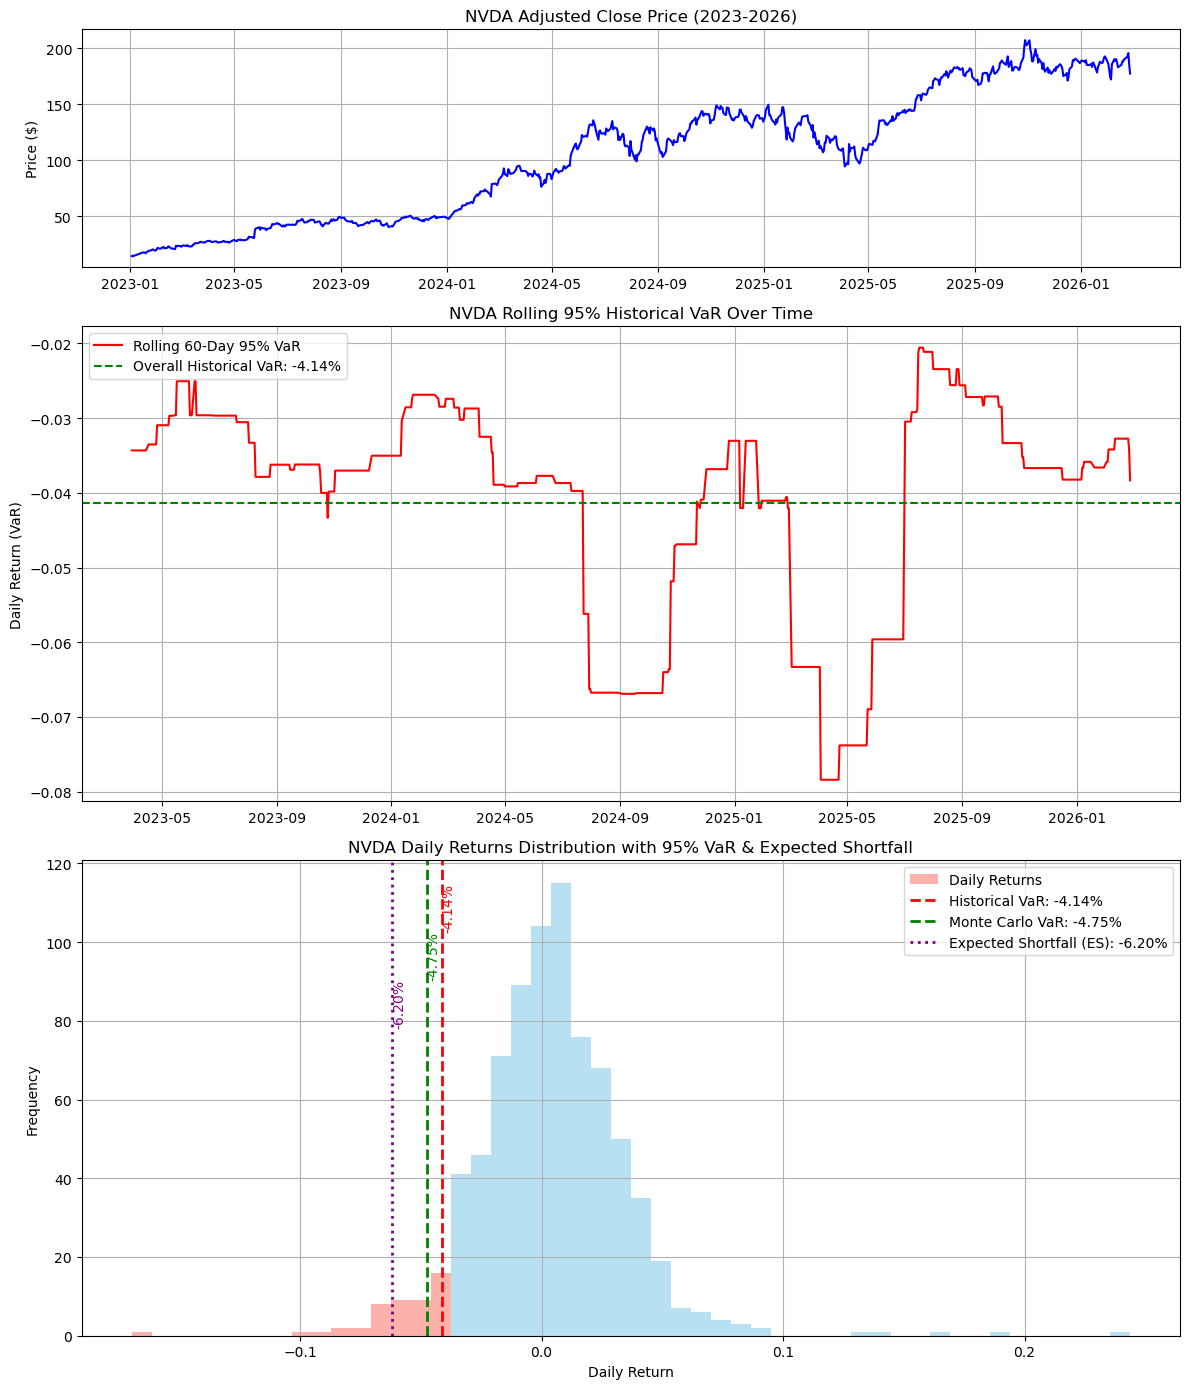


Sample Rolling 60-Day VaR (last 10 entries):
Price      VaR_rolling_60
Ticker                   
Date                     
2026-02-13      -0.032736
2026-02-17      -0.032736
2026-02-18      -0.032736
2026-02-19      -0.032736
2026-02-20      -0.032736
2026-02-23      -0.032736
2026-02-24      -0.032736
2026-02-25      -0.032736
2026-02-26      -0.034305
2026-02-27      -0.038325


In [20]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------
# 1. Download Data
# ------------------------------
nvda = yf.download('NVDA', start='2023-01-01', end='2026-03-01', auto_adjust=True)

# ------------------------------
# 2. Compute Daily Returns
# ------------------------------
nvda['Return'] = nvda['Close'].pct_change().dropna()

# ------------------------------
# 3. Descriptive Statistics
# ------------------------------
mean_return = nvda['Return'].mean()
std_return = nvda['Return'].std()
min_return = nvda['Return'].min()
max_return = nvda['Return'].max()

print("Descriptive Statistics:")
print(f"Mean Daily Return: {mean_return:.4%}")
print(f"Standard Deviation: {std_return:.4%}")
print(f"Minimum Daily Return: {min_return:.2%}")
print(f"Maximum Daily Return: {max_return:.2%}")

# ------------------------------
# 4. Value-at-Risk (VaR)
# ------------------------------
# Historical VaR (5th percentile)
VaR_hist = nvda['Return'].quantile(0.05)

# Monte Carlo Simulation VaR
mu = mean_return
sigma = std_return
simulations = np.random.normal(mu, sigma, 100000)
VaR_mc = np.percentile(simulations, 5)

# Expected Shortfall (Historical)
ES_hist = nvda['Return'][nvda['Return'] <= VaR_hist].mean()

print("\nValue-at-Risk (95% confidence):")
print(f"Historical VaR: {VaR_hist:.2%}")
print(f"Monte Carlo VaR: {VaR_mc:.2%}")
print(f"Historical Expected Shortfall (ES): {ES_hist:.2%}")

# ------------------------------
# 5. Rolling 60-Day Historical VaR
# ------------------------------
nvda['VaR_rolling_60'] = nvda['Return'].rolling(window=60).quantile(0.05)

# ------------------------------
# 6. Visualization
# ------------------------------

fig, axes = plt.subplots(3, 1, figsize=(12,14), gridspec_kw={'height_ratios':[1,2,2]})

# --- Plot 1: Closing Price over Time ---
axes[0].plot(nvda.index, nvda['Close'], color='blue')
axes[0].set_title('NVDA Adjusted Close Price (2023-2026)')
axes[0].set_ylabel('Price ($)')
axes[0].grid(True)

# --- Plot 2: Rolling 60-Day VaR ---
axes[1].plot(nvda.index, nvda['VaR_rolling_60'], color='r', label='Rolling 60-Day 95% VaR')
axes[1].axhline(VaR_hist, color='g', linestyle='dashed', label=f'Overall Historical VaR: {VaR_hist:.2%}')
axes[1].set_title('NVDA Rolling 95% Historical VaR Over Time')
axes[1].set_ylabel('Daily Return (VaR)')
axes[1].legend()
axes[1].grid(True)

# --- Plot 3: Histogram with Shaded 5% Worst Returns ---
counts, bins, patches = axes[2].hist(nvda['Return'], bins=50, alpha=0.6, label='Daily Returns', color='skyblue')
for patch, bin_edge in zip(patches, bins):
    if bin_edge <= VaR_hist:
        patch.set_facecolor('salmon')  # Shade worst 5% returns

# VaR Lines
axes[2].axvline(VaR_hist, color='r', linestyle='dashed', linewidth=2, label=f'Historical VaR: {VaR_hist:.2%}')
axes[2].axvline(VaR_mc, color='g', linestyle='dashed', linewidth=2, label=f'Monte Carlo VaR: {VaR_mc:.2%}')
# ES line
axes[2].axvline(ES_hist, color='purple', linestyle='dotted', linewidth=2, label=f'Expected Shortfall (ES): {ES_hist:.2%}')

# Annotate VaR and ES
axes[2].text(VaR_hist, axes[2].get_ylim()[1]*0.9, f'{VaR_hist:.2%}', color='r', rotation=90, verticalalignment='center')
axes[2].text(VaR_mc, axes[2].get_ylim()[1]*0.8, f'{VaR_mc:.2%}', color='g', rotation=90, verticalalignment='center')
axes[2].text(ES_hist, axes[2].get_ylim()[1]*0.7, f'{ES_hist:.2%}', color='purple', rotation=90, verticalalignment='center')

axes[2].set_title('NVDA Daily Returns Distribution with 95% VaR & Expected Shortfall')
axes[2].set_xlabel('Daily Return')
axes[2].set_ylabel('Frequency')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

# ------------------------------
# 7. Optional: Rolling VaR Table Snapshot
# ------------------------------
print("\nSample Rolling 60-Day VaR (last 10 entries):")
print(nvda[['VaR_rolling_60']].tail(10))

In [22]:
import yfinance as yf
import numpy as np
import pandas as pd

# Download Apple data
aapl = yf.download('AAPL', start='2023-01-01', end='2026-03-01', auto_adjust=True)

# Compute daily returns
aapl['Return'] = aapl['Close'].pct_change().dropna()

# Descriptive stats
aapl_mean = aapl['Return'].mean()
aapl_std = aapl['Return'].std()
aapl_min = aapl['Return'].min()
aapl_max = aapl['Return'].max()

# VaR & ES
aapl_VaR_hist = aapl['Return'].quantile(0.05)
simulations = np.random.normal(aapl_mean, aapl_std, 100000)
aapl_VaR_mc = np.percentile(simulations, 5)
aapl_ES_hist = aapl['Return'][aapl['Return'] <= aapl_VaR_hist].mean()

# Rolling 60-day VaR
aapl['VaR_rolling_60'] = aapl['Return'].rolling(window=60).quantile(0.05)

# Combine NVDA and AAPL for comparison table
comparison = pd.DataFrame({
    'Metric': ['Mean Return', 'Std Deviation', 'Min Return', 'Max Return', 'Historical VaR', 'Monte Carlo VaR', 'Expected Shortfall (ES)'],
    'NVDA': [nvda['Return'].mean(), nvda['Return'].std(), nvda['Return'].min(), nvda['Return'].max(), VaR_hist, VaR_mc, ES_hist],
    'AAPL': [aapl_mean, aapl_std, aapl_min, aapl_max, aapl_VaR_hist, aapl_VaR_mc, aapl_ES_hist]
})
print(comparison)

[*********************100%***********************]  1 of 1 completed

                    Metric      NVDA      AAPL
0              Mean Return  0.003672  0.001097
1            Std Deviation  0.031297  0.016199
2               Min Return -0.169682 -0.092456
3               Max Return  0.243696  0.153288
4           Historical VaR -0.041360 -0.024380
5          Monte Carlo VaR -0.047536 -0.025609
6  Expected Shortfall (ES) -0.061962 -0.036135
